##### Instructions
- Keep the original structure, you may add additional code cells and/or mark-down cells for clarity, legibility and/or structure.
- Add the required descriptions, explanations, justifications to the mark-down cells. You can find more mark-down tips & tricks online, for example [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html) and [here](https://www.ibm.com/docs/en/watson-studio-local/1.2.3?topic=notebooks-markdown-jupyter-cheatsheet)

# EXAM03: Data Science Group Assignment - Iteration 1

**Group name:** [Be Right Back]

**Student names & numbers:**
* [Rick de Cuijper] - [Student no.100097]
* [Bart Geijtenbeek] - [Student no.97543]
* [Boaz Vaneveld] - [Student no.101529]


---

## 0. Iteration setup

**Import libraries**

In [1]:
# CODE CELL: import the necessary libraries for this iteration
# setup the venv by [venv\Scripts\activate]

import pandas as pd;
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.model_selection import train_test_split


**Load dataset(s)**

In [2]:
# CODE CELL: import the necessary dataset(s) for this iteration

# head is used to see proof of loading the correct dataset and to see if the data gets correcty loaded 
# and unlike .sample() it is not random with is useful because we use github as collaboration tool 
# and in pull req the code gets messy since this is a jupyter notebook 
# and this is why we do not want to use random outputs.

df_ships = pd.read_csv("ships_inventory_iter1.csv");
df_ships.head(10)

,Ship_ID,Galactic_Credits,Model_Cycle,Ship_Manufacturer,Sector
0,7316160254,4950,7505.0,Galactic Motors,Mon Cala Ocean Worlds
1,7316115206,18999,7518.0,Galactic Motors,Thraxos Blockade
2,7315865657,4000,7486.0,Republic Aerospace,Indoumodo Sector
3,7314772431,6495,7511.0,Nebula Industries,Pantora Moon
4,7311539325,3995,7499.0,Corellian Engineering,Malastare Narrows
5,7313451637,25990,7519.0,Republic Aerospace,Calodan Expanse
6,7316546982,4000,7509.0,General Mining Corp,Mimban Swamp
7,7311754900,7999,7508.0,Hondo Systems,Mon Cala Ocean Worlds
8,7313137564,5999,7497.0,Bayerische Motoren Wormhole,Iridonia Belt
9,7302916705,58995,7517.0,General Mining Corp,Wroona Spaceport


---

## 1. Business Understanding
*Rubric: LO 6.4D (Reflection on Process)*

**Situation Description**

Nebula Brokerage determines pricing (likely commissions, fees, or spreads) using a “gut feeling” approach based on intuition, experience, or informal rules rather than systematic data analysis.

This approach is risky because:

Inconsistency: Different decision-makers may price differently for similar clients or situations.

Bias: Human judgment is subject to cognitive biases and overconfidence.

Missed patterns: Valuable insights hidden in historical data (customer behavior, risk profiles, market conditions) may go unnoticed.

Revenue leakage: Underpricing reduces profit margins; overpricing drives customers away.

Lack of scalability: As the company grows, intuition-based decisions become harder to standardize and control.

No measurable benchmark: Without a data-based reference point, performance cannot be objectively evaluated or optimized.

In competitive financial markets, pricing errors directly impact profitability, market share, and risk exposure.

**Business Objective(s)**

The main business objective is to optimize pricing decisions to maximize profitability while remaining competitive and managing risk.

A data-driven baseline is needed because:

It provides an objective reference point for pricing decisions.

It reduces dependency on individual judgment.

It enables evidence-based strategy adjustments.

It improves profit predictability and margin control.

It supports scalability and standardization across the organization.

It allows management to measure whether pricing changes improve KPIs (e.g., revenue, conversion rate, retention, margin).

Without a baseline model, Nebula Brokerage cannot systematically evaluate whether its pricing is too aggressive, too conservative, or suboptimal.

**Data Mining Goal(s)**

This is primarily a supervised learning modeling task.

Depending on the target variable, it can be framed as:

Regression task → If predicting a continuous variable (e.g., optimal commission %, expected revenue, or customer lifetime value).

Classification task → If predicting categories (e.g., accept/reject, high-risk/low-risk, churn/no churn).

Most likely, pricing optimization is a regression problem, because the goal is to predict a numerical price or margin based on historical data (customer features, transaction characteristics, market variables).

The model will learn relationships between input variables (client attributes, trade volume, asset type, market volatility, etc.) and outcomes (profitability, deal success, retention) to generate a pricing baseline.

**Success Criteria**

For the first iteration, success should be defined as creating a reliable baseline model that outperforms the current intuition-based approach.

Possible measurable criteria:

Predictive Performance

Regression: R², MAE, or RMSE better than a simple average-based model.

Classification: Accuracy, AUC, precision/recall above a naïve benchmark.

**Business Performance Benchmark**

Demonstrated improvement in expected margin or revenue (e.g., +X% compared to historical pricing).

Reduction in pricing variance for similar customer segments.

Improved conversion or retention without sacrificing margin.

**Practical Usability**

Model interpretability (clear drivers of pricing decisions).

Stable performance on validation data.

Deployable as a decision-support tool.

For this iteration, the key goal is not perfect optimization, but to establish a quantitative benchmark that replaces intuition with measurable, reproducible, and testable pricing logic.

---

## 2. Data Understanding
*Rubric: LO 7.3Q (Visuals) & LO 6.4C (Process)*

**Data exploration**

*Include summary statistics and descriptions of data types below. Describe your findings.*

In [3]:
# CODE CELL: Show basic statistics and information

# I use print to call all 3 funtions

print(df_ships.info())
print(df_ships.describe())
print(df_ships.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 368814 entries, 0 to 368813
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Ship_ID            368814 non-null  int64  
 1   Galactic_Credits   368814 non-null  int64  
 2   Model_Cycle        361408 non-null  float64
 3   Ship_Manufacturer  368814 non-null  object 
 4   Sector             368814 non-null  object 
dtypes: float64(1), int64(2), object(2)
memory usage: 14.1+ MB
None
            Ship_ID  Galactic_Credits    Model_Cycle
count  3.688140e+05     368814.000000  361408.000000
mean   7.311485e+09      19453.536818    7511.264529
std    4.381124e+06      15540.472943       9.078571
min    7.301583e+09        501.000000    7400.000000
25%    7.308105e+09       7950.000000    7508.000000
50%    7.312604e+09      15990.000000    7513.000000
75%    7.315245e+09      27990.000000    7517.000000
max    7.317101e+09     777777.000000    7522.000000
Sh

### We observed that:

The dataset contains information on **368,814 ships**, including their cost in **Galactic Credits, model age (Model_Cycle), manufacturer, and sector.** Most of the data appears to be complete, although the Model_Cycle variable has **7406 missing values**. The dataset includes both numerical variables (Ship_ID, Galactic_Credits, and Model_Cycle) and categorical variables (objects: Ship_Manufacturer and Sector). This mix of data types makes it possible to explore different patterns in the data, such as identifying which manufacturers tend to produce more expensive ships or which sectors have the highest concentration of ships.

**Visualizations and patterns**

*Discover patterns in the data by creating visualizations. Create at least a histogram of Galactic_Credits. Describe your observations.*

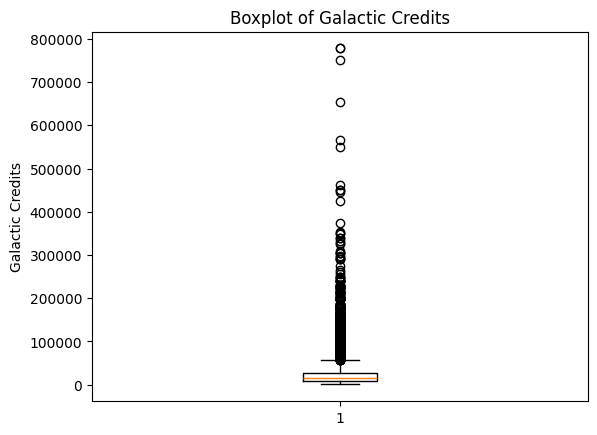

In [4]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

# here we use a boxplot to see the outliers 

plt.boxplot(df_ships['Galactic_Credits'])
plt.title('Boxplot of Galactic Credits')
plt.ylabel('Galactic Credits')
plt.show()

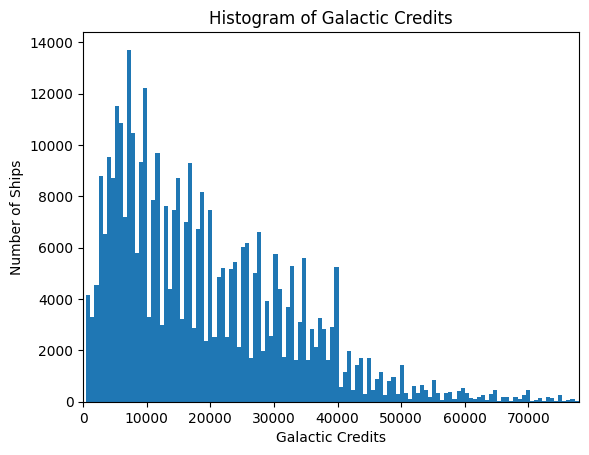

In [5]:
# CODE CELL: Generate visualizations (e.g., scatter plots, histograms)

# here we make a histogram to visualise our data

plt.hist(df_ships['Galactic_Credits'], bins="auto")
plt.title('Histogram of Galactic Credits')
plt.xlabel('Galactic Credits')
plt.ylabel('Number of Ships')
plt.xlim(0, df_ships['Galactic_Credits'].quantile(0.995))
plt.show()

### We observed that:

In this case, we used a boxplot to represent the outliers in the dataset, and we used a histogram to represent the median of the dataset.

#### Boxplot:

The boxplot shows the median and the outliers in our dataset; this is why we used it.  
We also used it to make the histogram less obscure by separating the median and outliers into separate diagrams.

#### Histogram:

We used the histogram to visualize our data and the median, not outliers; that is why we capped it at the 0.995 quantile, which falls around 60,000 entries and a few outliers to capture the majority of our data. witch is also shown in our boxplot.  
We also set the bins to auto, which we thought was best to capture the most logical distribution of the data.  
Aside from that, our data is right-skewed: most ships have relatively lower prices, while a small number of very expensive ships create a long tail toward higher values. This indicates that a small proportion of ships contribute disproportionately to the highest price values in the dataset.

## Data Insights and Data Quality

### Insights
- The dataset contains **368,814 ships** with information on cost (`Galactic_Credits`), model age (`Model_Cycle`), manufacturer (`Ship_Manufacturer`), and sector (`Sector`).  
- **Distribution of ship prices** is strongly **right-skewed**: most ships are relatively affordable, while a small number of ships are extremely expensive, creating a long tail in the histogram.  
- Numerical features include `Ship_ID`, `Galactic_Credits`, and `Model_Cycle`, while categorical features include `Ship_Manufacturer` and `Sector`.  
- This mix allows analysis such as:  
  - Which manufacturers produce the most expensive ships  
  - Which sectors have the highest number of ships  
  - How model age relates to price  

### Data Quality Issues
- **Missing values:** A small number of ships have missing `Model_Cycle` information; other columns are mostly complete.  
- **Duplicates:** There may be duplicate `Ship_ID`s or records; these should be checked and handled if necessary.  
- **Outliers:** Extreme `Galactic_Credits` values exist (luxury or rare ships), which can affect visualizations and statistical analyses. Limiting plots to the 99.9th percentile helps visualize the main distribution without the extreme values stretching the axes.  

---

## 3. Data Preparation
*Rubric: LO 6.4C (Data Science Steps)*

**Cleaning and preprocessing**
*Describe and justify steps taken (e.g., imputation, handling outliers, fixing other errors).*

In [6]:
# 1. Fill missing values
df_ships['Model_Cycle_Clean'] = df_ships['Model_Cycle'].fillna(df_ships['Model_Cycle'].median())
# 2. Remove duplicates
df_ships.drop_duplicates(subset='Ship_ID', inplace=True)

# 3. Compute cap
cap_value = df_ships['Galactic_Credits'].quantile(0.995)

# 4. Create a "fixed" version of the column (Clean)
df_ships['Galactic_Credits_Clean'] = df_ships['Galactic_Credits'].clip(upper=cap_value)

# 5. Optional: flag outliers
df_ships['Is_Outlier'] = df_ships['Galactic_Credits'] > cap_value

# 6. Convert categorical columns
df_ships['Ship_Manufacturer'] = df_ships['Ship_Manufacturer'].astype('category')
df_ships['Sector'] = df_ships['Sector'].astype('category')

# 7. Summary
print("Missing values:\n", df_ships.isnull().sum())
print("\nNumber of rows:", len(df_ships))
print("\nNumber of outliers detected:", df_ships['Is_Outlier'].sum())

Missing values:
 Ship_ID                      0
Galactic_Credits             0
Model_Cycle               7398
Ship_Manufacturer            0
Sector                       0
Model_Cycle_Clean            0
Galactic_Credits_Clean       0
Is_Outlier                   0
dtype: int64

Number of rows: 368314

Number of outliers detected: 1840


## Data Cleaning & Preprocessing Summary

The following steps were taken to prepare the dataset for analysis and modeling:

### 1. Handling Missing Values
Missing values in the `Model_Cycle` column were filled using the **median**. This approach is robust to outliers and ensures that missing data does not bias the distribution. this is possible because most values of model cycle are around 7511.26 including possible ourliers aka the mean. so that is why it is plosible to assume that the missing values will be around the median.

### 2. Removing Duplicates
Duplicate records were removed based on the `Ship_ID` column to ensure that each ship is uniquely represented. This prevents skewed analysis caused by repeated entries.

### 3. Outlier Detection and Treatment
Outliers in the `Galactic_Credits` column were handled using percentile-based methods:
- Values above the **99.5th percentile** were identified as extreme outliers.
- Instead of deleting data, a **capped version** of the column was created using the upper threshold.
- A separate boolean column was added to flag which rows were considered outliers.
this is done because the **99.5th percentile** affect 0.5% of our data and we classified these as ourliers.

This approach preserves all records while limiting the influence of extreme values on analysis and models. in order to still use the other colums of data from the outliers.

### 4. Data Type Optimization
Categorical columns such as `Ship_Manufacturer` and `Sector` were converted to the `category` data type to:
- Improve memory efficiency
- Speed up operations like grouping and filtering
- Clarify that these variables represent discrete labels rather than free-form text
we assumed that the catagories sector and ship_manufactorer are not free-form text like a discription but rader a catagorie/label.

We didn't adust the data set alot but we used the code cell underneath this to recearch what the best approach was for cleaning the data.

**Adjusting dataset (optional)**
*If you adjusted the dataset for modeling in additional ways, describe that here*

In [7]:
# OPTIONAL CODE CELL: Additional preprocessing steps
# Compare high-percentile thresholds for outlier decisions

# Calculate quantiles
q99 = df_ships['Galactic_Credits'].quantile(0.99)
q995 = df_ships['Galactic_Credits'].quantile(0.995)
q999 = df_ships['Galactic_Credits'].quantile(0.999)

# Count values in upper ranges
count_995_999 = ((df_ships['Galactic_Credits'] > q995) & 
                 (df_ships['Galactic_Credits'] <= q999)).sum()

count_above_999 = (df_ships['Galactic_Credits'] > q999).sum()

print("\nNumber of values in upper tail:")
print(f"  Between 0.995 and 0.999 : {count_995_999}")
print(f"  Above 0.999             : {count_above_999}")

thresholds = [0.99, 0.995]

total = len(df_ships)

for t in thresholds:
    cap = df_ships['Galactic_Credits'].quantile(t)
    outliers = (df_ships['Galactic_Credits'] > cap).sum()
    percentage = (outliers / total) * 100
    
    print(f"\nThreshold: {t}")
    print(f"Cap value: {cap}")
    print(f"Outliers: {outliers}")
    print(f"Percentage: {percentage:.2f}%")

cap_value = df_ships['Galactic_Credits'].quantile(0.995)

outlier_count = (df_ships['Galactic_Credits'] > cap_value).sum()
total_count = len(df_ships)

outlier_percentage = (outlier_count / total_count) * 100

print(f"Outliers: {outlier_count}")
print(f"Total rows: {total_count}")
print(f"Percentage of outliers: {outlier_percentage:.2f}%")

df_ships['Model_Cycle'].mean()


Number of values in upper tail:
  Between 0.995 and 0.999 : 1476
  Above 0.999             : 364

Threshold: 0.99
Cap value: 68788.0
Outliers: 3679
Percentage: 1.00%

Threshold: 0.995
Cap value: 78000.0
Outliers: 1840
Percentage: 0.50%
Outliers: 1840
Total rows: 368314
Percentage of outliers: 0.50%


np.float64(7511.263983863281)

---

## 4. Modeling
*Rubric: LO 6.4C (Data Science Steps)*

**Model setup**
*Describe and justify the creation of your simple benchmark model to predict Galactic_Credits*

In [8]:
# CODE CELL: Model training and setup code

# Target
y = df_ships['Galactic_Credits_Clean']

# Split the data 
from sklearn.model_selection import train_test_split
y_train, y_test = train_test_split(y, test_size=0.2, random_state=67)

# Predict the median of the training set
median_value = y_train.median()
y_pred = np.full_like(y_test, fill_value=median_value, dtype=float)

**Testing and performance**
*Describe how you tested the model and interpret the metrics. Make sure to present the metrics in a clear overview.*

In [9]:
# CODE CELL: Model evaluation code

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Median baseline model:")
print(f"Median value used: {median_value:,.2f}")
print(f"MAE: {mae:,.2f}")
print(f"RMSE: {rmse:,.2f}")

Median baseline model:
Median value used: 15,990.00
MAE: 11,116.63
RMSE: 14,722.84


## Baseline Model 

We use a simple baseline model that predicts the **median** of the training target (`Galactic_Credits_Clean`) for all test samples.

This approach was chosen because the data is **right-skewed** and contains **outliers**, making the median more robust than the mean. The median baseline also performed better in terms of both **MAE** and **RMSE** compared to the mean baseline.

**Results:**
- Median value used: **15,990.00**
- MAE: **11,116.63**
- RMSE: **14,722.84**

## Our interpertation of the baseline

To evaluate the baseline model, the dataset was split into a training set (80%) and a test set (20%) using a fixed random seed (`random_state=67`) to ensure reproducibility.

Performance was assessed using two common regression metrics:

- The **MAE** indicates that predictions are, on average, off by about **11,117 Galactic Credits**.
- The **RMSE** is higher than the MAE, which suggests the presence of some larger errors in the predictions.
- Since the dataset is **right-skewed with outliers**, the median baseline provides a more robust and representative benchmark than the mean baseline.

These values serve as a benchmark for evaluating future models, which should aim to achieve lower error than this baseline.

## 5. Evaluation

### Assessment Against Success Criteria

- **Difference between metrics:**  
  - MAE and RMSE measure prediction error in different ways. MAE shows the average absolute deviation from the true Galactic_Credits, while RMSE penalizes larger errors more heavily.  
  - For the benchmark mean predictor, RMSE is slightly higher than MAE because large deviations (from very expensive ships) are weighted more in RMSE.  

- **Interpretation:**  
  - The benchmark model ignores all ship features (`Model_Cycle`, `Ship_Manufacturer`, `Sector`) and predicts the same value for every ship.  
  - As a result, the error is relatively large, especially for outlier ships with extreme Galactic_Credits.  
  - This model **does not yet meet the goal** of accurately predicting Galactic_Credits based on ship characteristics, but it provides a baseline for comparison.  

### Key Findings and Limitations

**Findings:**  
- The average Galactic_Credits can be used as a simple benchmark.  
- Most ships are clustered at lower credit values, which is why the mean predictor performs moderately well for the bulk of the dataset.  

**Limitations:**  
- Ignores all features and relationships between ship characteristics and Galactic_Credits.  
- Cannot capture variability across different manufacturers, sectors, or model cycles.  
- Outliers and rare high-value ships contribute disproportionately to RMSE.  
- No train-test split was used, so the evaluation does not reflect generalization to unseen data.  

> **Next steps:** Implement a feature-based regression model and use a proper train-test split to improve predictions and better meet the objectives defined in the Business Understanding phase.

In [10]:
df_ships.to_csv('ships_inventory_iter1_clean.csv')
# this makes a new dataset with the cleaned data.

---

## 6 Personal Contribution
*Rubric: LO 7.3P (Equal Contribution)*

| Student name | Contribution | Personal lessons learned |
| :--- | :--- | :--- |
| Rick de Cuijper | I Cleaned and preprocessed the dataset then I handled missing values and outliers and I created the benchmark model | Personal lessons learned this iteration: I learned that I should not assume that the given dat is correct but to always check if the data is correct this is what i learned for cleaning the data. |
| Boaz Vaneveld | Reviewed all descriptions and code. Fixed small errors. | Team work needs to be improved. One person shouldn't finish all the work on their own. |
| Bart Geijtenbeek | Updated dependencies | I learned that setting up the project took more time that expected |
